In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk spacy wordcloud

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached cloudpathlib-0.24.0-py3-none-any.whl.metadata (16 kB)
  Using cached smart_open-7.6.1-py3-none-any.whl.metadata (25 kB)
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 4.0 MB/s eta 0:00:04
   --- ------------------------------------ 1.3/14.2 MB 3.4 MB/s eta 0:00:04
   ----- ---------------------------------- 2.1/14.2 MB 4.0 MB/s eta 0:00:04
   --------- ------------------------------ 3.4/14.2 MB 4.5 MB/s eta 0:00:03
   ------------- -------------------------- 4.7/14.2 MB 4.8 MB/s eta 0:00:02
   -------

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud

In [4]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SATHWIK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SATHWIK\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SATHWIK\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
nlp = spacy.load("en_core_web_sm")

In [7]:
resume_df = pd.read_csv("../data/resumes/Resume.csv")
job_df = pd.read_csv("../data/job_descriptions/monster_com-job_sample.csv")
skills_df = pd.read_csv("../data/skills/skills.csv")

In [8]:
resume_df.head()
resume_df.info()
resume_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


(2484, 4)

In [9]:
job_df.head()
job_df.info()
job_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          22000 non-null  object
 1   country_code     22000 non-null  object
 2   date_added       122 non-null    object
 3   has_expired      22000 non-null  object
 4   job_board        22000 non-null  object
 5   job_description  22000 non-null  object
 6   job_title        22000 non-null  object
 7   job_type         20372 non-null  object
 8   location         22000 non-null  object
 9   organization     15133 non-null  object
 10  page_url         22000 non-null  object
 11  salary           3446 non-null   object
 12  sector           16806 non-null  object
 13  uniq_id          22000 non-null  object
dtypes: object(14)
memory usage: 2.3+ MB


(22000, 14)

In [10]:
skills_df.head()

,Skill
0,Python
1,SQL
2,Machine Learning
3,Deep Learning
4,Data Analysis


In [11]:
# Keep only useful columns
resume_df = resume_df[['ID', 'Resume_str', 'Category']]

# Keep only useful job columns
job_df = job_df[['job_title', 'job_description']]

print(resume_df.head())
print(job_df.head())

         ID                                         Resume_str Category
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...       HR
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...       HR
2  33176873           HR DIRECTOR       Summary      Over 2...       HR
3  27018550           HR SPECIALIST       Summary    Dedica...       HR
4  17812897           HR MANAGER         Skill Highlights  ...       HR
                                           job_title  \
0               IT Support Technician Job in Madison   
1            Business Reporter/Editor Job in Madison   
2  Johnson & Johnson Family of Companies Job Appl...   
3                    Engineer - Quality Job in Dixon   
4       Shift Supervisor - Part-Time Job in Camphill   

                                     job_description  
0  TeamSoft is seeing an IT Support Specialist to...  
1  The Wisconsin State Journal is seeking a flexi...  
2  Report this job About the Job DePuy Synthes Co...  
3  Why Join

In [12]:
print("Resume Dataset")
print(resume_df.isnull().sum())

print("\nJob Dataset")
print(job_df.isnull().sum())

Resume Dataset
ID            0
Resume_str    0
Category      0
dtype: int64

Job Dataset
job_title          0
job_description    0
dtype: int64


In [13]:
job_df.dropna(subset=['job_description'], inplace=True)

In [14]:
resume_df.drop_duplicates(inplace=True)
job_df.drop_duplicates(inplace=True)

print("Resume Shape:", resume_df.shape)
print("Job Shape:", job_df.shape)

Resume Shape: (2484, 3)
Job Shape: (20617, 2)


In [15]:
import re
import string

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove phone numbers
    text = re.sub(r'\d{10,}', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [16]:
resume_df["clean_resume"] = resume_df["Resume_str"].apply(clean_text)

job_df["clean_job"] = job_df["job_description"].apply(clean_text)

In [17]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [18]:
resume_df["processed_resume"] = resume_df["clean_resume"].apply(preprocess_text)

job_df["processed_job"] = job_df["clean_job"].apply(preprocess_text)

In [19]:
resume_df[["Resume_str", "processed_resume"]].head()

,Resume_str,processed_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist u hr operation summary versatile...
2,HR DIRECTOR Summary Over 2...,hr director summary year experience recruiting...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlight hr skill hr departm...


In [20]:
job_df[["job_description", "processed_job"]].head()

,job_description,processed_job
0,TeamSoft is seeing an IT Support Specialist to...,teamsoft seeing support specialist join client...
1,The Wisconsin State Journal is seeking a flexi...,wisconsin state journal seeking flexible motiv...
2,Report this job About the Job DePuy Synthes Co...,report job job depuy synthes company member jo...
3,Why Join Altec? If you’re considering a career...,join altec you’re considering career altec inc...
4,Position ID# 76162 # Positions 1 State CT C...,position id position state ct city fairfield c...


In [21]:
skill_list = skills_df["Skill"].str.lower().tolist()

print(skill_list[:10])

['python', 'sql', 'machine learning', 'deep learning', 'data analysis', 'data science', 'nlp', 'tensorflow', 'pytorch', 'keras']


In [29]:
import re

def extract_skills(text, skill_list):
    text = text.lower()
    found_skills = []

    for skill in skill_list:
        # Match complete words or phrases only
        pattern = r'\b' + re.escape(skill.lower()) + r'\b'

        if re.search(pattern, text):
            found_skills.append(skill)

    return sorted(list(set(found_skills)))

In [30]:
resume_df["skills"] = resume_df["processed_resume"].apply(
    lambda x: extract_skills(x, skill_list)
)

In [31]:
job_df["required_skills"] = job_df["processed_job"].apply(
    lambda x: extract_skills(x, skill_list)
)

In [32]:
resume_df[["processed_resume", "skills"]].head()

,processed_resume,skills
0,hr administratormarketing associate hr adminis...,[data analysis]
1,hr specialist u hr operation summary versatile...,[communication]
2,hr director summary year experience recruiting...,[excel]
3,hr specialist summary dedicated driven dynamic...,"[communication, excel]"
4,hr manager skill highlight hr skill hr departm...,"[excel, problem solving]"


In [33]:
job_df[["job_title", "required_skills"]].head()

,job_title,required_skills
0,IT Support Technician Job in Madison,[communication]
1,Business Reporter/Editor Job in Madison,[]
2,Johnson & Johnson Family of Companies Job Appl...,"[communication, excel]"
3,Engineer - Quality Job in Dixon,[communication]
4,Shift Supervisor - Part-Time Job in Camphill,[]


In [34]:
from collections import Counter

all_skills = []

for skills in resume_df["skills"]:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.items(),
    columns=["Skill", "Count"]
).sort_values(by="Count", ascending=False)

top_skills.head(10)

,Skill,Count
1,communication,1451
2,excel,954
3,problem solving,422
4,c,281
6,sql,175
9,html,147
0,data analysis,128
11,linux,84
5,java,66
10,javascript,56


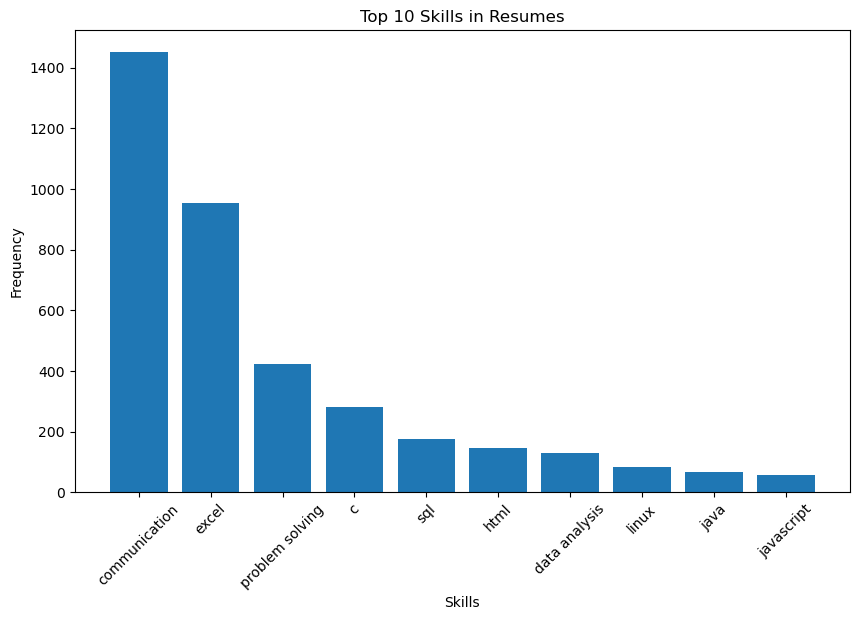

In [35]:
plt.figure(figsize=(10,6))

plt.bar(
    top_skills["Skill"][:10],
    top_skills["Count"][:10]
)

plt.xticks(rotation=45)

plt.title("Top 10 Skills in Resumes")

plt.xlabel("Skills")

plt.ylabel("Frequency")

plt.show()

In [59]:
job_index = 6822

selected_job = job_df[
    job_df["job_title"].str.contains(
        "Machine Learning Engineer",
        case=False,
        na=False
    )
].iloc[0]

print("Job Title:")
print(selected_job["job_title"])

print("\nRequired Skills:")
print(selected_job["required_skills"])

Job Title:
Machine Learning Engineer

Required Skills:
['data science', 'machine learning', 'spark']


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

documents = [selected_job["processed_job"]] + resume_df["processed_resume"].tolist()

tfidf_matrix = vectorizer.fit_transform(documents)

In [61]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

resume_df["Similarity Score"] = similarity_scores.flatten()

In [62]:
ranked_candidates = resume_df.sort_values(
    by="Similarity Score",
    ascending=False
).reset_index(drop=True)

ranked_candidates.head(10)

,ID,Resume_str,Category,clean_resume,processed_resume,skills,Similarity Score
0,26958533,"ENGINEER Summary Work Ethic,...",HEALTHCARE,engineer summary work ethic personal ownership...,engineer summary work ethic personal ownership...,[excel],0.151834
1,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,ENGINEERING,engineering and quality technician career over...,engineering quality technician career overview...,"[c, data analysis, data visualization, html, m...",0.143350
2,12351749,SALES COORDINATOR Summary Cu...,SALES,sales coordinator summary current ms of data a...,sale coordinator summary current m data analyt...,"[c, communication, data analysis, excel, machi...",0.127763
3,24508725,FIELD HR ASSOCIATE Summary ...,HR,field hr associate summary reliable hr field a...,field hr associate summary reliable hr field a...,"[communication, excel]",0.123943
4,57667857,HR CONSULTANT Summary Detai...,HR,hr consultant summary detailoriented years hum...,hr consultant summary detailoriented year huma...,[],0.104606
5,12777487,ONLINE LEARNING COORDINATOR - PROGRAM...,ARTS,online learning coordinator program training a...,online learning coordinator program training s...,[],0.103324
6,18835363,PROGRAM MANAGER & DESIGNER ...,DESIGNER,program manager designer professional summary ...,program manager designer professional summary ...,[],0.102708
7,18297650,VOLUNTEER HR -IVOLUNTEER Summar...,HR,volunteer hr ivolunteer summary sponsorship no...,volunteer hr ivolunteer summary sponsorship re...,"[c, communication, java, linux, sql]",0.100712
8,29087505,CONSTRUCTION WORK Career Over...,CONSTRUCTION,construction work career overview highly skill...,construction work career overview highly skill...,[problem solving],0.100592
9,24610685,SALES ENGINEER Summary I...,SALES,sales engineer summary i am currently looking ...,sale engineer summary currently looking advanc...,"[communication, excel, html, javascript, mysql...",0.094980


In [63]:
def matched_skills(candidate_skills, required_skills):
    return list(set(candidate_skills).intersection(set(required_skills)))

def missing_skills(candidate_skills, required_skills):
    return list(set(required_skills) - set(candidate_skills))

In [64]:
required = selected_job["required_skills"]

ranked_candidates["Matched Skills"] = ranked_candidates["skills"].apply(
    lambda x: matched_skills(x, required)
)

ranked_candidates["Missing Skills"] = ranked_candidates["skills"].apply(
    lambda x: missing_skills(x, required)
)

In [65]:
ranked_candidates[
    [
        "Category",
        "Similarity Score",
        "Matched Skills",
        "Missing Skills"
    ]
].head(10)

,Category,Similarity Score,Matched Skills,Missing Skills
0,HEALTHCARE,0.151834,[],"[data science, spark, machine learning]"
1,ENGINEERING,0.143350,[machine learning],"[data science, spark]"
2,SALES,0.127763,[machine learning],"[data science, spark]"
3,HR,0.123943,[],"[data science, spark, machine learning]"
4,HR,0.104606,[],"[data science, spark, machine learning]"
5,ARTS,0.103324,[],"[data science, spark, machine learning]"
6,DESIGNER,0.102708,[],"[data science, spark, machine learning]"
7,HR,0.100712,[],"[data science, spark, machine learning]"
8,CONSTRUCTION,0.100592,[],"[data science, spark, machine learning]"
9,SALES,0.094980,[],"[data science, spark, machine learning]"


In [66]:
print(selected_job["job_title"])
print()
print(selected_job["required_skills"])

Machine Learning Engineer

['data science', 'machine learning', 'spark']


In [67]:
job_df[
    job_df["job_title"]
    .str.contains("data", case=False, na=False)
][["job_title"]].head(20)

,job_title
9,Video Data Management /Transportation Technici...
227,Database Architect Job in Denver
335,Data Entry Job in Las Vegas
358,Data Entry Clerk - Business Casual Environment...
371,CyberCoders Job Application for Senior Databas...
397,Data Entry Job in Tampa
624,Data Center Wintel Admin Job in Dallas
667,Data Entry Clerk Job in Englewood
724,Senior Database Administrator Job in Dallas
869,Data Analyst (Intelligence Analyst) at USPIS J...


In [68]:
job_df[
    job_df["job_title"].str.contains(
        "data scientist|machine learning|ai|artificial intelligence",
        case=False,
        na=False,
        regex=True
    )
][["job_title"]]

,job_title
2,Johnson & Johnson Family of Companies Job Appl...
7,Mailroom Clerk Job in Austin
27,Traveling Customer Training Professional Job i...
34,Associate Product Developer Job in Saint Louis
54,Retail Merchandise Apprenticeship- Full Time &...
...,...
21950,Driver Trainee Job in Cincinnati
21957,Retail Sales Consultant Cincinnati OH (Cincinn...
21972,Restaurant Manager - Retail Food Service Manag...
21978,Cincinnati Job Fair Job in Cincinnati


In [69]:
job_df[
    job_df["job_title"].str.contains(
        r"\bdata scientist\b|\bmachine learning\b|\bartificial intelligence\b|\bAI\b",
        case=False,
        na=False,
        regex=True
    )
][["job_title"]]

,job_title
1433,Sr. Machine Learning Scientist Job in Seattle
2932,Senior Data Scientist
6822,Machine Learning Engineer
7422,Data Scientist - Immediate and Perm Job in Las...
12245,CyberCoders Job Application for Data Scientist...
12324,CyberCoders Job Application for Sr Data Scient...
17310,Data Scientist Job in Dallas
17862,Principal Member of Technical Staff Data Scien...
21431,Technical Architect - Data Scientist Job in Ci...
21521,Data Scientist


In [71]:
ranked_candidates["Similarity Score"] = (
    ranked_candidates["Similarity Score"] * 100
).round(2)

In [72]:
ranked_candidates.reset_index(drop=True, inplace=True)

ranked_candidates["Rank"] = ranked_candidates.index + 1

In [73]:
final_results = ranked_candidates[
    [
        "Rank",
        "Category",
        "Similarity Score",
        "Matched Skills",
        "Missing Skills"
    ]
]

final_results.head(10)

,Rank,Category,Similarity Score,Matched Skills,Missing Skills
0,1,HEALTHCARE,15.18,[],"[data science, spark, machine learning]"
1,2,ENGINEERING,14.33,[machine learning],"[data science, spark]"
2,3,SALES,12.78,[machine learning],"[data science, spark]"
3,4,HR,12.39,[],"[data science, spark, machine learning]"
4,5,HR,10.46,[],"[data science, spark, machine learning]"
5,6,ARTS,10.33,[],"[data science, spark, machine learning]"
6,7,DESIGNER,10.27,[],"[data science, spark, machine learning]"
7,8,HR,10.07,[],"[data science, spark, machine learning]"
8,9,CONSTRUCTION,10.06,[],"[data science, spark, machine learning]"
9,10,SALES,9.50,[],"[data science, spark, machine learning]"


In [74]:
final_results.to_csv(
    "../outputs/ranked_candidates.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


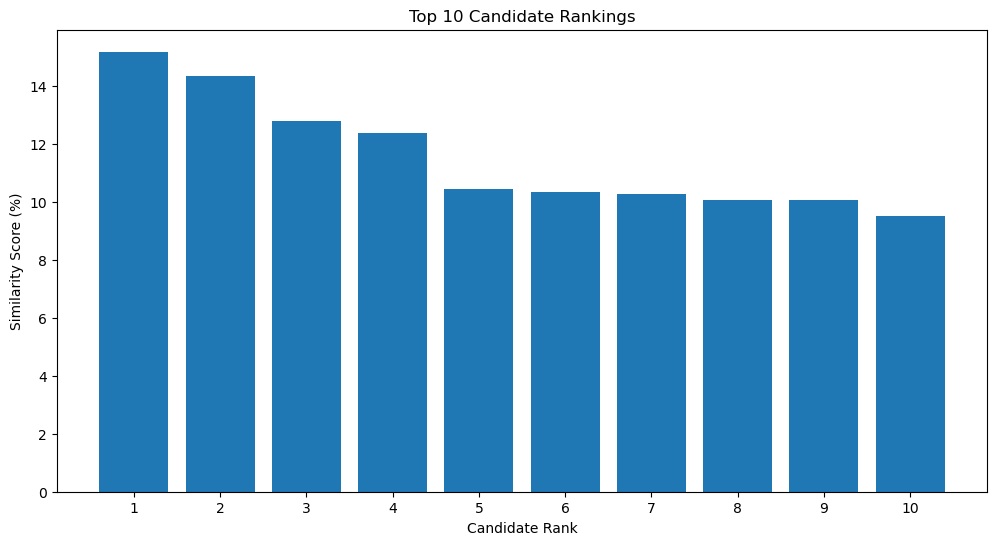

In [75]:
plt.figure(figsize=(12,6))

plt.bar(
    final_results["Rank"][:10].astype(str),
    final_results["Similarity Score"][:10]
)

plt.xlabel("Candidate Rank")
plt.ylabel("Similarity Score (%)")
plt.title("Top 10 Candidate Rankings")

plt.show()

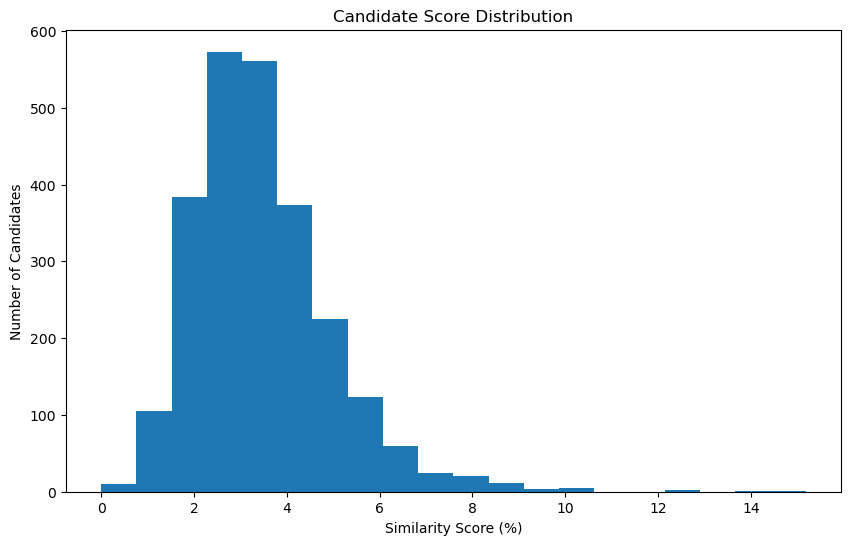

In [76]:
plt.figure(figsize=(10,6))

plt.hist(
    ranked_candidates["Similarity Score"],
    bins=20
)

plt.xlabel("Similarity Score (%)")
plt.ylabel("Number of Candidates")
plt.title("Candidate Score Distribution")

plt.show()

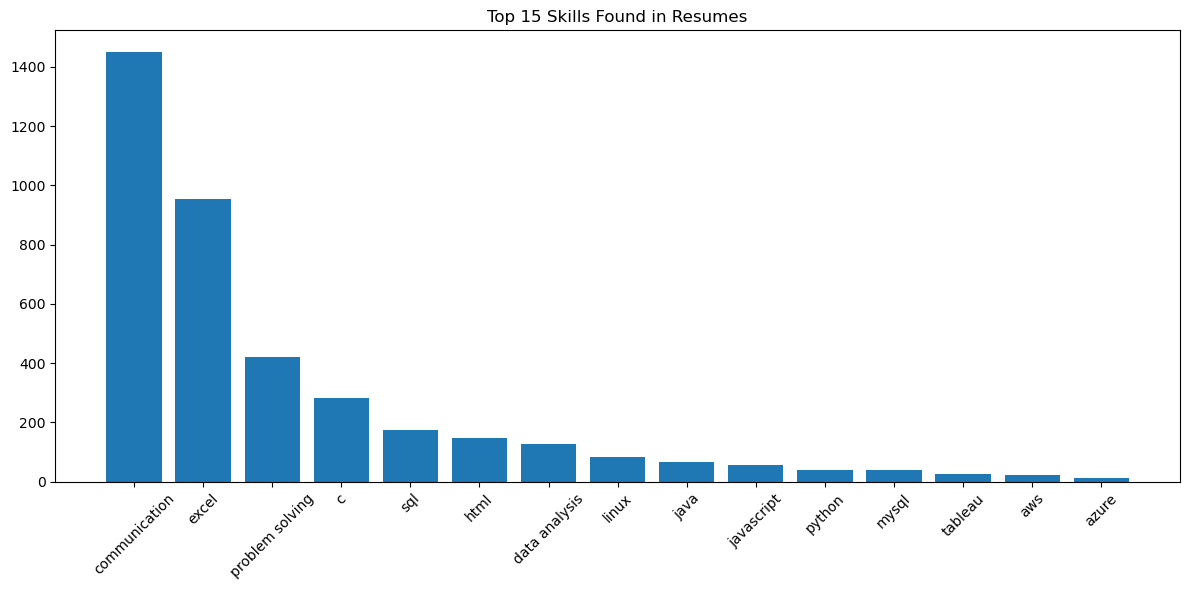

In [77]:
plt.figure(figsize=(12,6))

plt.bar(
    top_skills["Skill"][:15],
    top_skills["Count"][:15]
)

plt.xticks(rotation=45)

plt.title("Top 15 Skills Found in Resumes")

plt.tight_layout()

plt.show()

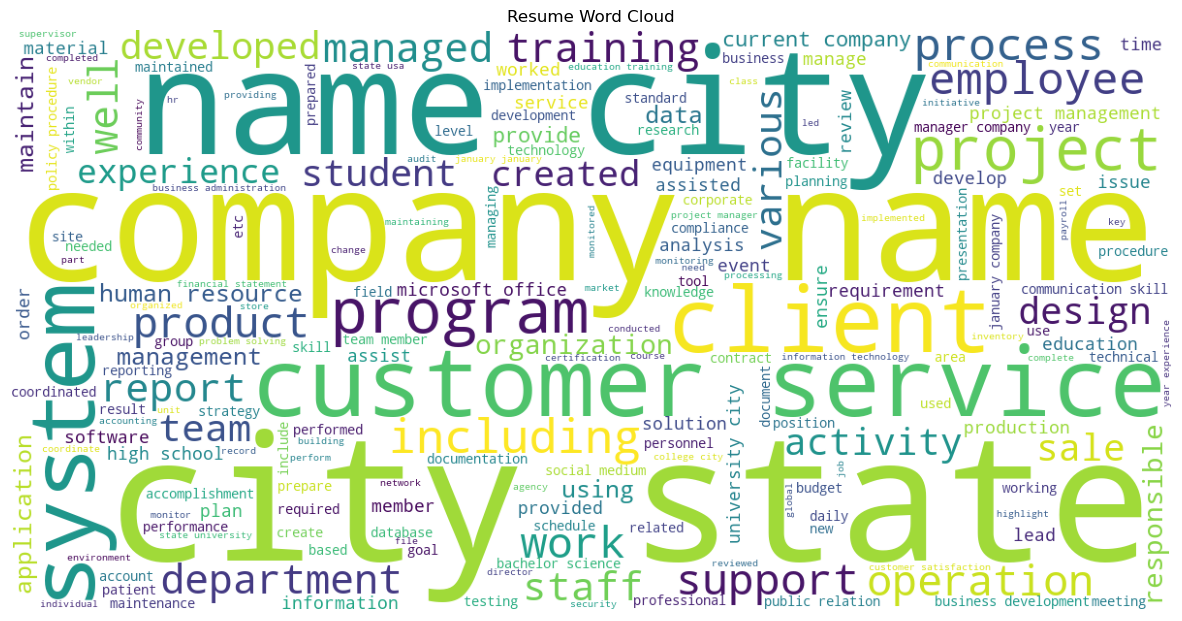

In [78]:
from wordcloud import WordCloud

text = " ".join(resume_df["processed_resume"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume Word Cloud")

plt.show()

In [80]:
plt.savefig(
    "../outputs/plots/ranking_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [81]:
print("="*60)

print("AI Resume Screening Summary")

print("="*60)

print(f"Total Resumes : {len(resume_df)}")

print(f"Job Role : {selected_job['job_title']}")

print(f"Top Candidate Score : {final_results.iloc[0]['Similarity Score']}%")

print(f"Top Candidate Category : {final_results.iloc[0]['Category']}")

print("="*60)

AI Resume Screening Summary
Total Resumes : 2484
Job Role : Machine Learning Engineer
Top Candidate Score : 15.18%
Top Candidate Category : HEALTHCARE


In [82]:
import os

print(os.getcwd())

c:\Users\SATHWIK\OneDrive\Documents\FURUTE_ML_03\FUTURE_ML_03\notebooks


In [83]:
import os

os.makedirs("outputs", exist_ok=True)

final_results.to_csv(
    "outputs/ranked_candidates.csv",
    index=False
)

print("CSV Saved Successfully!")

CSV Saved Successfully!
